# Clusterização de dados: aplicação prática em Python
Este notebook demonstra conceitos de clusterização e sistemas de recomendação com Python, usando os temas do material e do mapa mental.

- Mapa mental do tema: [2-clusterização-de-dados.md](../../../docs/mapas-mentais/01-aprendizado-de-maquina-overview/2-clusterização-de-dados.md)

Os objetivos são:
- aplicar algoritmos de clusterização (K-Means, Agglomerative, DBSCAN, Affinity Propagation)
- avaliar a qualidade dos clusters com métricas de similaridade
- montar um exemplo simples de recomendação baseado em filtragem colaborativa


## 1. Instalação de dependências
Execute esta célula se os pacotes ainda não estiverem instalados no ambiente.

In [1]:
#!pip install --quiet scikit-learn pandas matplotlib seaborn scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, AffinityPropagation
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Geração de dados sintéticos para segmentação de clientes
Usamos um exemplo de grupo de clientes para demonstrar a clusterização.
Cada ponto representa um cliente e seus atributos de comportamento de compra.

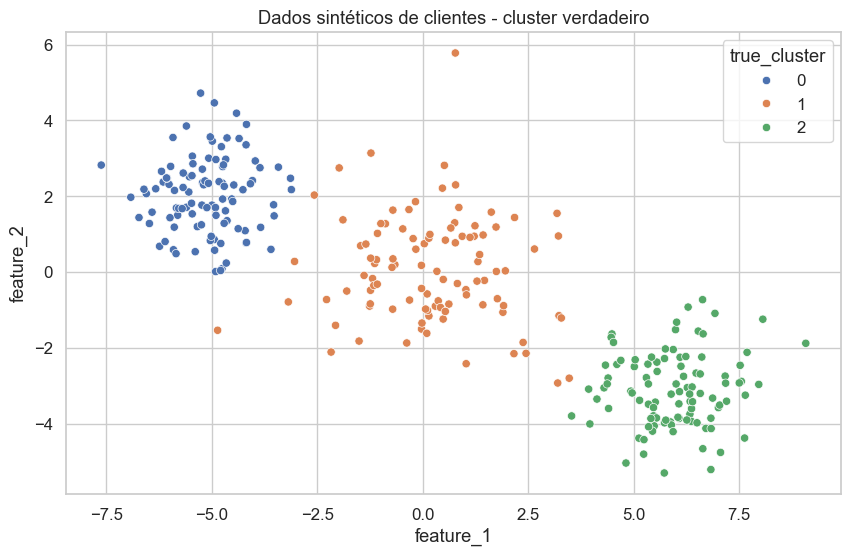

In [3]:
X, y_true = make_blobs(n_samples=300,
                       centers=[[-5, 2], [0, 0], [6, -3]],
                       cluster_std=[1.0, 1.5, 1.0],
                       random_state=42)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['true_cluster'] = y_true

plt.figure()
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='true_cluster', palette='deep')
plt.title('Dados sintéticos de clientes - cluster verdadeiro')
plt.show()

## 3. K-Means
K-Means é um método de particionamento que exige a escolha prévia do número de clusters (K).
É um algoritmo iterativo que calcula centroides e reatribui pontos até convergência.

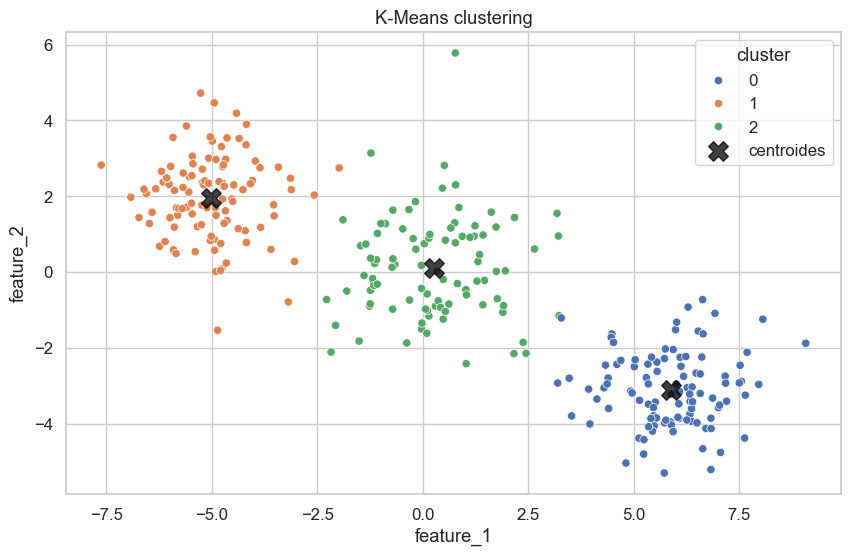

Silhouette score do K-Means: 0.649


In [4]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X)

plt.figure()
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='kmeans_cluster', palette='deep')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, alpha=0.75, marker='X', label='centroides')
plt.legend(title='cluster')
plt.title('K-Means clustering')
plt.show()

sil_kmeans = silhouette_score(X, df['kmeans_cluster'])
print(f'Silhouette score do K-Means: {sil_kmeans:.3f}')

## 4. Clusterização Hierárquica Aglomerativa
Hierarchical Clustering cria uma árvore de agrupamentos e pode ser usado em modo aglomerativo ou divisivo.
A seguir usamos Agglomerative Clustering (HAC).

In [ ]:
agg = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['agg_cluster'] = agg.fit_predict(X)

plt.figure()
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='agg_cluster', palette='deep')
plt.title('Agglomerative Clustering (ward)')
plt.show()

sil_agg = silhouette_score(X, df['agg_cluster'])
print(f'Silhouette score do Agglomerative: {sil_agg:.3f}')

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

## 5. DBSCAN
DBSCAN é um método baseado em densidade que encontra clusters de forma arbitrária e identifica ruído.
Parâmetros principais:
- eps: distância máxima para vizinhança
- min_samples: número mínimo de pontos na vizinhança

In [ ]:
dbscan = DBSCAN(eps=1.6, min_samples=8)
df['dbscan_cluster'] = dbscan.fit_predict(X)

plt.figure()
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='dbscan_cluster', palette='deep', legend='full')
plt.title('DBSCAN clustering')
plt.show()

labels = df['dbscan_cluster']
if len(set(labels)) > 1 and -1 not in set(labels):
    sil_dbscan = silhouette_score(X, labels)
    print(f'Silhouette score do DBSCAN: {sil_dbscan:.3f}')
else:
    noise = (labels == -1).sum()
    print(f'DBSCAN identificou {noise} pontos como ruído e {len(set(labels))- (1 if -1 in set(labels) else 0)} clusters.')

## 6. Affinity Propagation
Affinity Propagation identifica o número de clusters automaticamente usando troca de mensagens entre os pontos.

Siglas:
- AP: Affinity Propagation
- damping: fator que controla a oscilação de mensagens entre exemplos

In [ ]:
affinity = AffinityPropagation(damping=0.75, random_state=42)
df['ap_cluster'] = affinity.fit_predict(X)

plt.figure()
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='ap_cluster', palette='deep')
plt.title('Affinity Propagation')
plt.show()

sil_ap = silhouette_score(X, df['ap_cluster'])
print(f'Silhouette score do Affinity Propagation: {sil_ap:.3f}')
print('Número de clusters encontrados:', len(np.unique(df['ap_cluster'])))

## 7. Avaliação de clusterização
Métricas importantes:
- Silhouette Score: avalia coesão interna e separação entre clusters
- Adjusted Rand Index (ARI): compara a divisão obtida com rótulos verdadeiros
- Adjusted Mutual Information (AMI): mede concordância entre duas partições

No contexto de dados não rotulados, as métricas internas como Silhouette são mais usadas.

In [ ]:
ami = adjusted_mutual_info_score(df['true_cluster'], df['kmeans_cluster'])
ari = adjusted_rand_score(df['true_cluster'], df['kmeans_cluster'])
print(f'Adjusted Mutual Information (K-Means): {ami:.3f}')
print(f'Adjusted Rand Index (K-Means): {ari:.3f}')

## 8. Exemplo de sistema de recomendação simples
Vamos aplicar um exemplo de recomendação baseada em filtragem colaborativa usando similaridade entre usuários.

Este exemplo usa uma matriz de interações usuário-item e recomenda itens com base em usuários semelhantes.

In [ ]:
ratings = pd.DataFrame({
    'user_id': [1, 1, 1, 2, 2, 3, 3, 4, 4, 5],
    'item_id': [101, 102, 103, 101, 104, 102, 105, 101, 103, 104],
    'rating': [5, 4, 3, 4, 5, 2, 5, 3, 4, 4]
})

user_item = ratings.pivot_table(index='user_id', columns='item_id', values='rating').fillna(0)
user_item

In [ ]:
# Similaridade entre usuários usando cosseno
user_sim = cosine_similarity(user_item)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)
user_sim_df

In [ ]:
def recommend_for_user(user_id, top_n=3):
    if user_id not in user_item.index:
        return []
    similarities = user_sim_df.loc[user_id]
    weighted_ratings = user_item.T.dot(similarities) / similarities.sum()
    recommended = weighted_ratings[user_item.loc[user_id] == 0].sort_values(ascending=False)
    return recommended.head(top_n)

print('Recomendações para o usuário 1:')
print(recommend_for_user(1))
print('\nRecomendações para o usuário 4:')
print(recommend_for_user(4))

## 9. Observações e próximos passos
- A clusterização ajuda a segmentar clientes ou padrões em dados não rotulados.
- Métricas internas como Silhouette e métricas externas como AMI/ARI são úteis para avaliar resultados.
- Sistemas de recomendação podem usar dados de interação para sugerir itens semelhantes.
- No caso real, a escolha do algoritmo depende de:
  - formato dos dados
  - escala do problema
  - presença de ruído
  - necessidade de número fixo de clusters

### Referências
- K-Means, DBSCAN, AgglomerativeClustering e AffinityPropagation: scikit-learn
- Filtragem colaborativa: similaridade de usuários e itens
- Cold-start: maior desafio em sistemas de recomendação com usuários ou itens novos